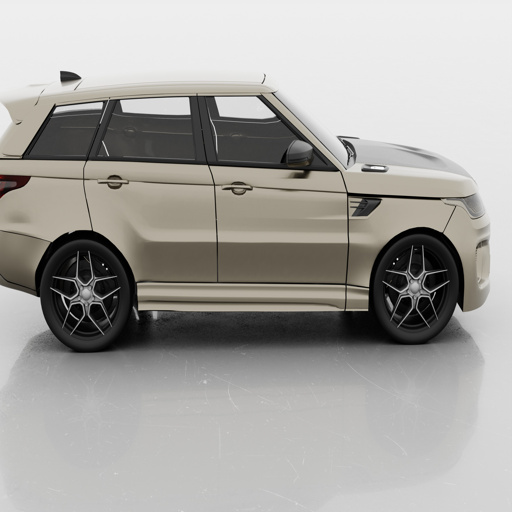

In [1]:
from PIL import Image
import numpy as np
import cv2
image_path = "data/shadow-gen/stepho_renderings/reflections_4/train/land-rover-reflection_0058.jpg"
image = Image.open(image_path)

im_arr = np.array(image)
image.resize((512,512))
#TODO Make FFT transform + homographic filtering to segment reflections

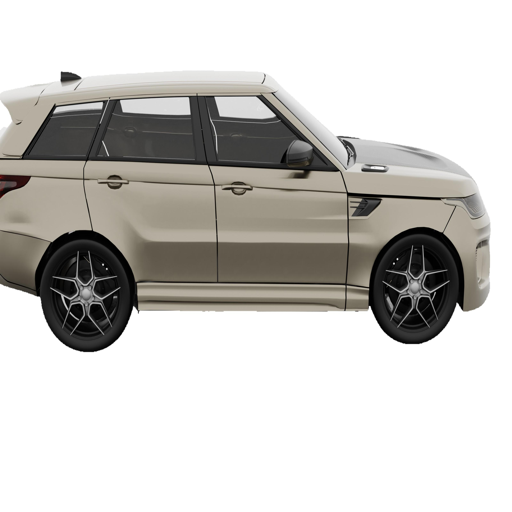

In [2]:
# cut = Image.open("data/shadow-gen/stepho_renderings/reflections_4/train/audi-reflection_0001_cut.jpg")
cut_path = image_path.replace(".jpg", "_cut.jpg")

cut = Image.open(cut_path)
cut.resize((512,512))

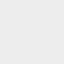

In [3]:
bg_color = im_arr[10,10]
bg_sample = np.zeros((64,64, 3))
bg_sample[:] = bg_color
Image.fromarray(bg_sample.astype(np.uint8))

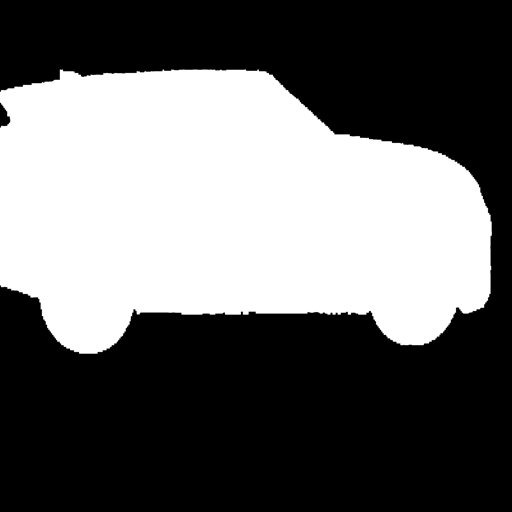

In [4]:
import numpy as np
import cv2
# cut_path = image_path.replace(".jpg", "_cut.jpg")
# cut = Image.open(cut_path)
# bg = np.array(image) - np.array(cut)
# Image.fromarray(bg)
# bg
car_mask = (np.array(cut) < 255).astype(np.uint8)[:,:,0]
car_mask = cv2.dilate(car_mask, np.ones((3,3), np.uint8), iterations=5)
car_mask = cv2.erode(car_mask, np.ones((3,3), np.uint8), iterations=3)
Image.fromarray(car_mask*255, mode='L').resize((512,512))
# (np.array(cut) < 255).astype(np.uint8)*255

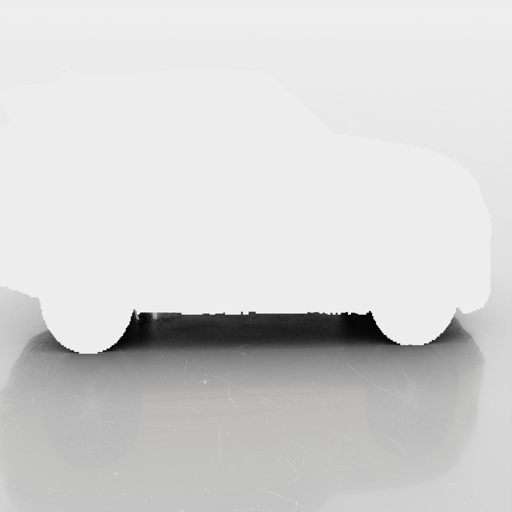

In [5]:
masked_im = im_arr.copy()
masked_im[car_mask != 0] = bg_color
Image.fromarray(masked_im.astype(np.uint8)).resize((512,512))

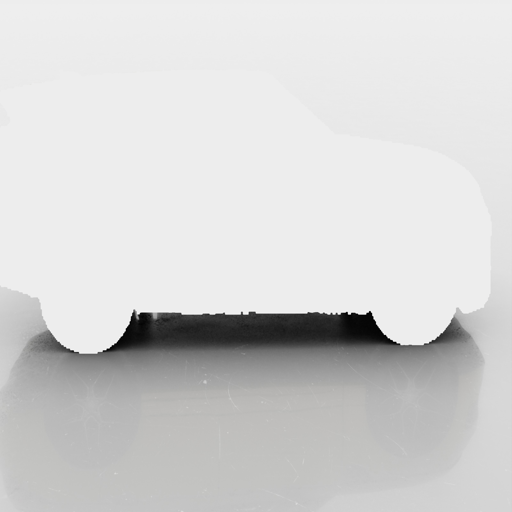

In [6]:
a=cv2.medianBlur(masked_im, 5)
Image.fromarray(a.astype(np.uint8)).resize((512,512))

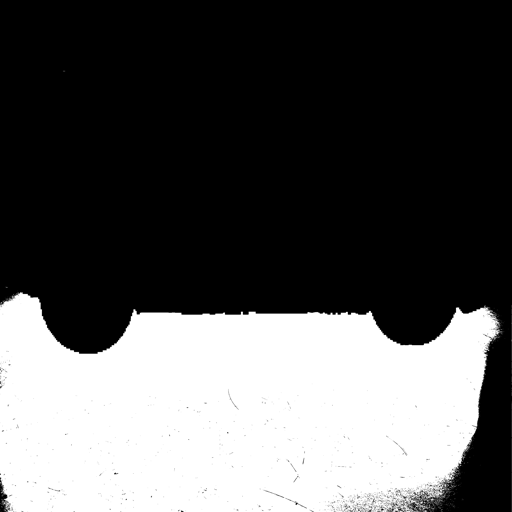

In [10]:
import skimage
# Convert the masked image to grayscale
gray_masked_im_otsu = cv2.cvtColor(masked_im, cv2.COLOR_RGB2GRAY)

otsu_thresh = skimage.filters.threshold_multiotsu(gray_masked_im_otsu, classes=3)
a=(gray_masked_im_otsu < otsu_thresh[1]).astype(np.uint8) * 255
Image.fromarray(a, mode='L').resize((512,512))
# Image.fromarray(a.astype(np.uint8), mode='L').resize((512,512))

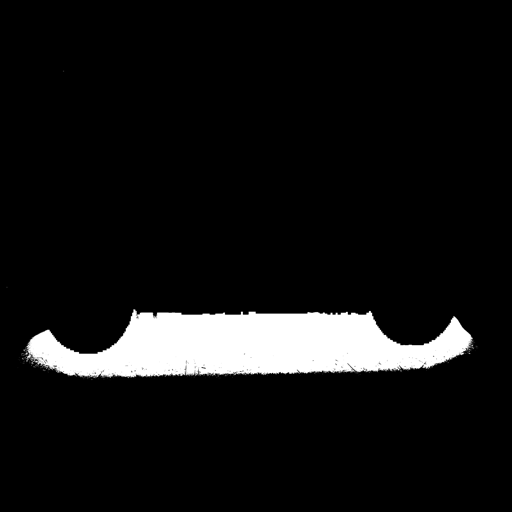

In [143]:
# Convert the masked image to grayscale
gray_masked_im_otsu = cv2.cvtColor(masked_im, cv2.COLOR_RGB2GRAY)

# Apply Otsu's thresholding
# We use THRESH_BINARY_INV because the reflections are darker than the background
ret, otsu_thresh = cv2.threshold(gray_masked_im_otsu, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

refl_mask = otsu_thresh
# Display the resulting mask
Image.fromarray(otsu_thresh, mode='L').resize((512, 512))

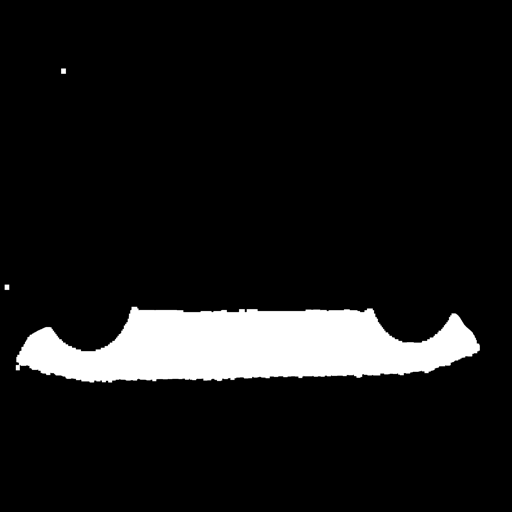

In [144]:
dilated_mask = cv2.dilate(refl_mask, np.ones((3,3), np.uint8), iterations=12)
Image.fromarray((dilated_mask).astype(np.uint8), mode='L').resize((512,512))

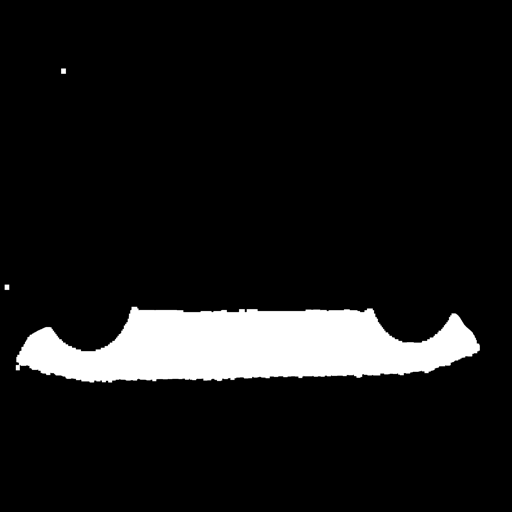

In [145]:
opened_mask = cv2.morphologyEx(dilated_mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8), iterations=8)
Image.fromarray((opened_mask).astype(np.uint8), mode='L').resize((512,512))

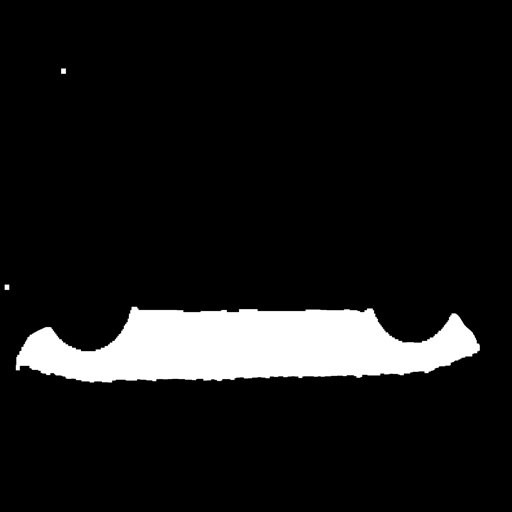

In [146]:
closed_mask = cv2.morphologyEx(opened_mask, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=8)
Image.fromarray((closed_mask).astype(np.uint8), mode='L').resize((512,512))

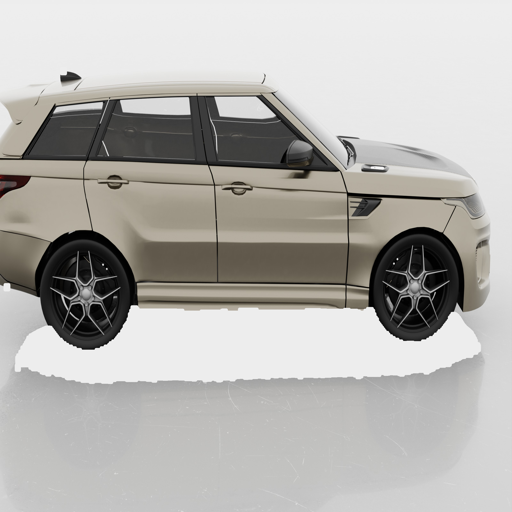

In [147]:
# Overlay the mask on the original image
blurred_mask = cv2.GaussianBlur(closed_mask, (15, 15), 0)
Image.fromarray((blurred_mask).astype(np.uint8), mode='L').resize((512,512))

# Apply the mask to the original image
masked_im = im_arr.copy()
masked_im[blurred_mask != 0] = bg_color
Image.fromarray(masked_im.astype(np.uint8)).resize((512,512))

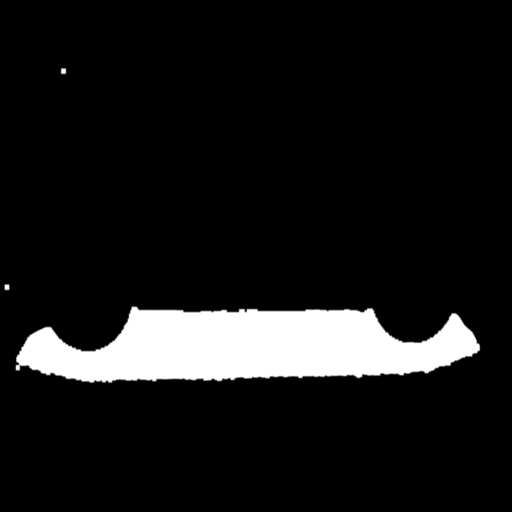

In [148]:
blurred_mask = cv2.GaussianBlur(opened_mask, (15, 15), 0)
Image.fromarray((blurred_mask).astype(np.uint8), mode='L').resize((512,512))